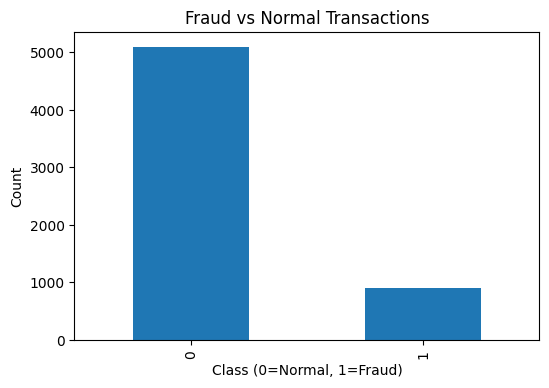

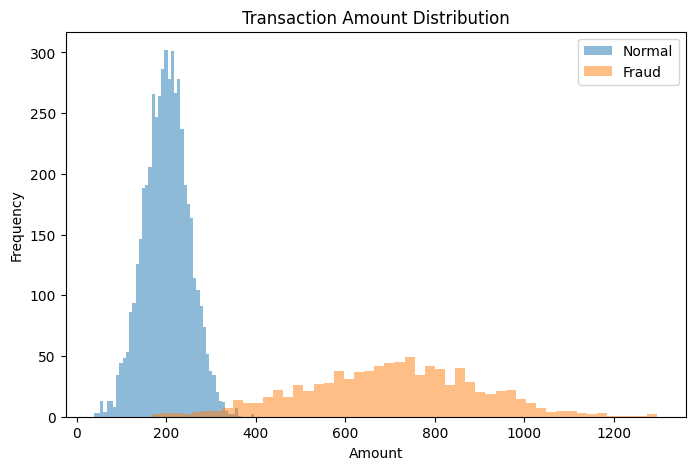

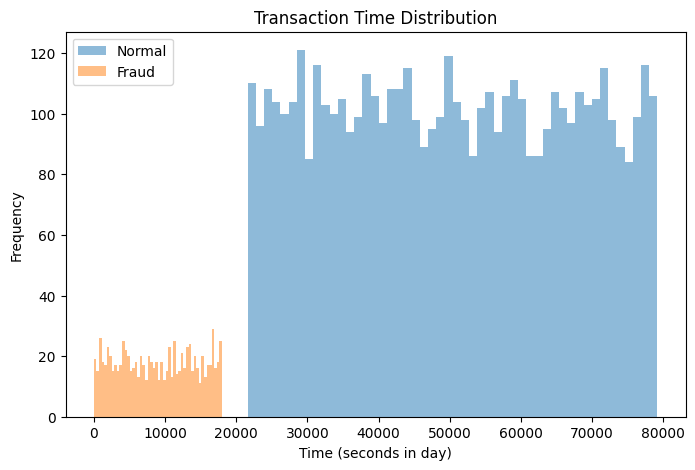

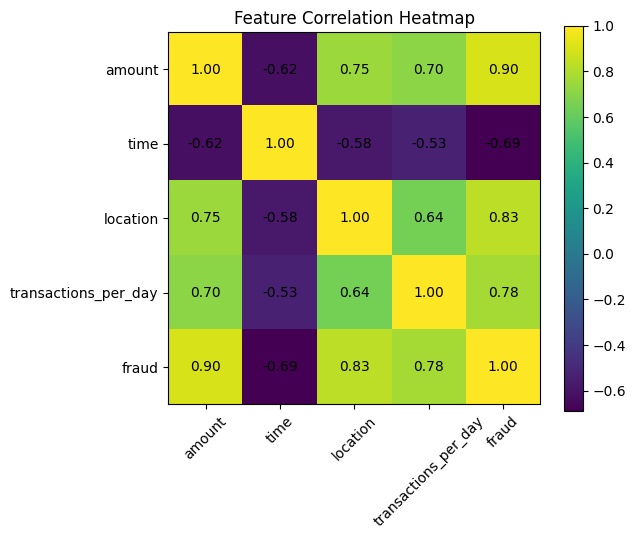

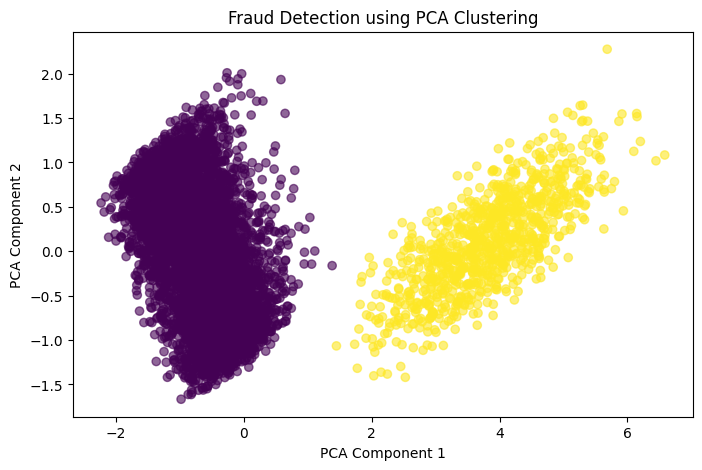

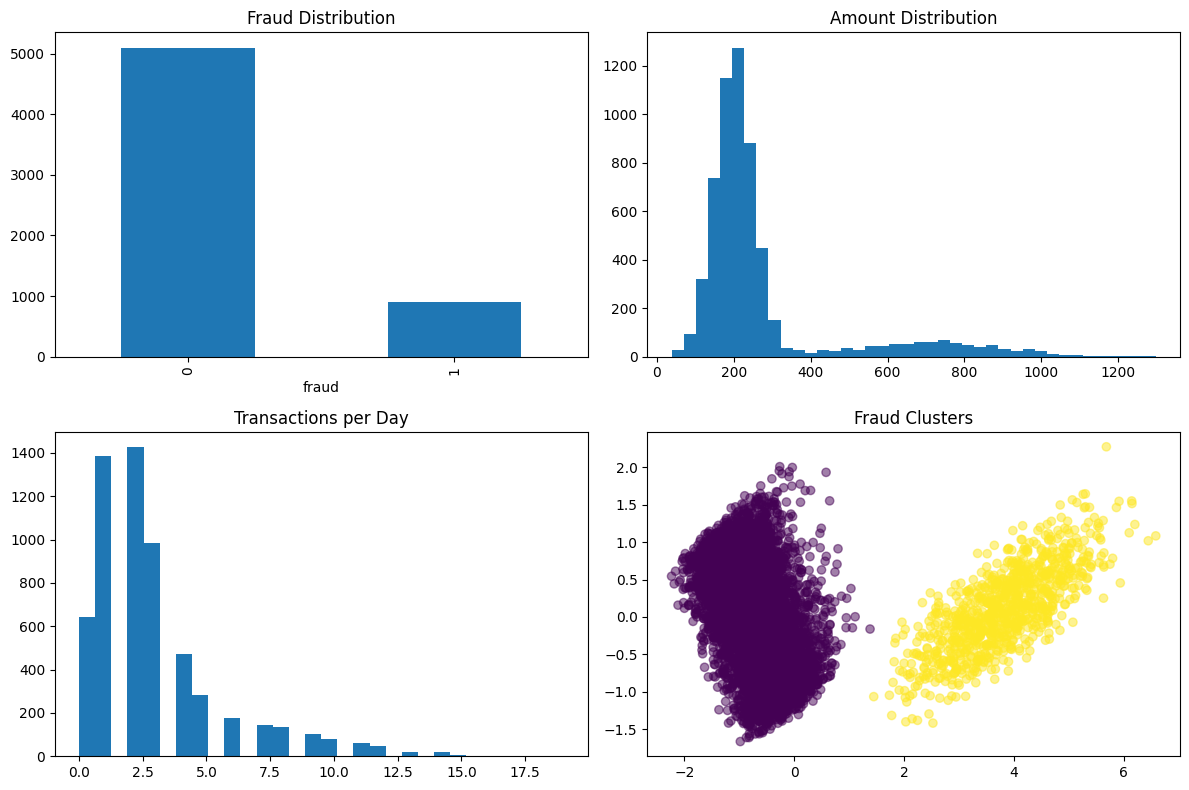

In [1]:
#visualising fraud pattern & Analytics

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. GENERATE REALISTIC FRAUD DATA
np.random.seed(42)
n_samples = 6000

# Normal transactions
normal = pd.DataFrame({
    "amount": np.random.normal(200, 50, int(n_samples*0.85)),
    "time": np.random.randint(6*3600, 22*3600, int(n_samples*0.85)),
    "location": np.random.randint(1, 30, int(n_samples*0.85)),
    "transactions_per_day": np.random.poisson(2, int(n_samples*0.85)),
    "fraud": 0
})

# Fraud patterns
fraud = pd.DataFrame({
    "amount": np.random.normal(700, 200, int(n_samples*0.15)),
    "time": np.random.randint(0, 5*3600, int(n_samples*0.15)),
    "location": np.random.randint(30, 80, int(n_samples*0.15)),
    "transactions_per_day": np.random.poisson(8, int(n_samples*0.15)),
    "fraud": 1
})

# Combine dataset
data = pd.concat([normal, fraud], ignore_index=True)
data["amount"] = data["amount"].clip(lower=1)

# 3. DATA IMBALANCE VISUALIZATION
plt.figure(figsize=(6,4))
data["fraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

# 4. TRANSACTION AMOUNT ANALYSIS
plt.figure(figsize=(8,5))
plt.hist(data[data["fraud"]==0]["amount"], bins=50, alpha=0.5, label="Normal")
plt.hist(data[data["fraud"]==1]["amount"], bins=50, alpha=0.5, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 5. TIME-BASED FRAUD ANALYSIS
plt.figure(figsize=(8,5))
plt.hist(data[data["fraud"]==0]["time"], bins=50, alpha=0.5, label="Normal")
plt.hist(data[data["fraud"]==1]["time"], bins=50, alpha=0.5, label="Fraud")
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds in day)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 6. CORRELATION HEATMAP
corr = data.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha='center', va='center')

plt.show()

# 7. CLUSTERING (PCA VISUALIZATION)
features = data.drop("fraud", axis=1)

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,5))
plt.scatter(pca_result[:,0], pca_result[:,1],
            c=data["fraud"], alpha=0.6)

plt.title("Fraud Detection using PCA Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# 8. SIMPLE DASHBOARD (MULTI-PLOT VIEW)
fig, axs = plt.subplots(2, 2, figsize=(12,8))

# Class imbalance
data["fraud"].value_counts().plot(kind="bar", ax=axs[0,0])
axs[0,0].set_title("Fraud Distribution")

# Amount
axs[0,1].hist(data["amount"], bins=40)
axs[0,1].set_title("Amount Distribution")

# Transactions/day
axs[1,0].hist(data["transactions_per_day"], bins=30)
axs[1,0].set_title("Transactions per Day")

# PCA scatter
axs[1,1].scatter(pca_result[:,0], pca_result[:,1],
                c=data["fraud"], alpha=0.5)
axs[1,1].set_title("Fraud Clusters")

plt.tight_layout()
plt.show()